In [3]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Dataset

import pathlib
import cv2

import os

In [2]:
text_vocab = [i for i in range(3)]
text_vocab

[0, 1, 2]

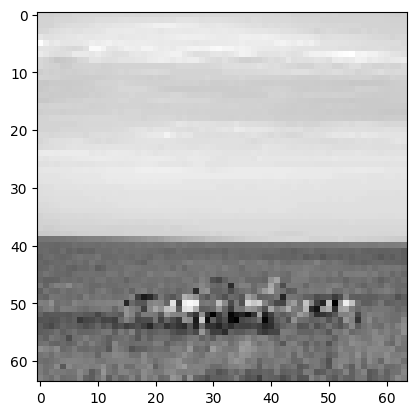

In [4]:
root = pathlib.Path("Data")

image = plt.imread(pathlib.Path.joinpath(root, "1.jpg"))
image_norm = cv2.cvtColor(cv2.resize(image, (64, 64)), cv2.COLOR_RGB2GRAY)

plt.imshow(image_norm, cmap="gray")

In [5]:
torch.tensor(image_norm).view(1, image_norm.shape[-1], -1).shape

torch.Size([1, 64, 64])

In [6]:
X = torch.rand(1, 64, 64)
patch_size = 8
patches = X.unfold(1, patch_size, patch_size).unfold(2, patch_size, patch_size) # (C, patch_row, patch_col, patch_h, patch_w)
patches = patches.permute(1, 2, 0, 3, 4)                                        # (patch_row, patch_col, C, patch_h, patch_w)
patch_row, patch_col, C, patch_h, patch_w = patches.shape
patches = patches.contiguous().view(patch_row * patch_col , C * patch_h * patch_w)
patches.shape

torch.Size([64, 64])

In [26]:
text_vocab   = [i.split(".")[0] for i in os.listdir(root)]
text_vocab[0]

'63'

In [46]:
items = [i.split(".")[0] for i in os.listdir(root)]
vocab_idx_2_file = {i: items[i] for i in range(len(items))}
vocab_file_2_idx = {v: k for k, v in vocab_idx_2_file.items()}
vocab_size = len(items)

torch.Size([1, 16, 256])


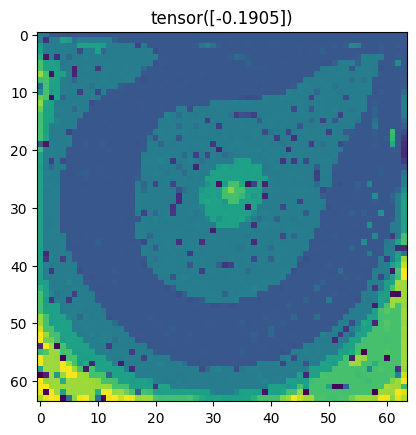

In [58]:
class Image_Dataset(Dataset):

    def __init__(self, root: str = "Data", patch_size: int = 8):
        super().__init__()

        root = pathlib.Path(root)

        self.re_list      = []
        self.text_list    = []
        self.images_list  = []
        self.patches_list = []
        
        files = os.listdir(root)

        for file in files:
            re_value = float(file.split(".jpg")[0])

            image = plt.imread(pathlib.Path.joinpath(root, file))
            image_norm = cv2.cvtColor(cv2.resize(image, (64, 64)), cv2.COLOR_RGB2GRAY)
            image_norm = image_norm.astype(np.float32) / 255.0
            
            image_norm_tensor = torch.tensor(image_norm).unsqueeze(0)

            patches = image_norm_tensor.unfold(1, patch_size, patch_size).unfold(2, patch_size, patch_size) # [C, patch_row, patch_col, patch_h, patch_w]
            patches = patches.permute(1, 2, 0, 3, 4)                                                        # [patch_row, patch_col, C, patch_h, patch_w]
            patch_row, patch_col, C, patch_h, patch_w = patches.shape
            patches = patches.contiguous().view(patch_row * patch_col , C * patch_h * patch_w)              # [num_patches, patch_dim]

            self.images_list.append(image_norm)
            self.patches_list.append(patches)
            self.re_list.append(re_value)
        
        self.re_mean = np.mean(self.re_list)
        self.re_std  = np.std(self.re_list)

    def __len__(self): return len(self.re_list)
    
    def __getitem__(self, index):
        re_value = self.re_list[index]

        # normalize Reynolds number
        re_norm = (re_value - self.re_mean) / self.re_std
        re_tensor = torch.tensor([re_norm], dtype=torch.float32)
        return (re_tensor, self.images_list[index], self.patches_list[index])

image_dataset = Image_Dataset(root = "Data_Re", patch_size=16)
dataloader    = DataLoader(image_dataset, batch_size = 1, shuffle = True)

text, image, patches = next(iter(dataloader))

print(patches.shape)

plt.imshow(image[0])
plt.title(text[0])
plt.show()

In [35]:
image.shape

torch.Size([1, 64, 64])

In [114]:
patches.shape

torch.Size([1, 64, 64])